In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['figure.dpi'] = 100

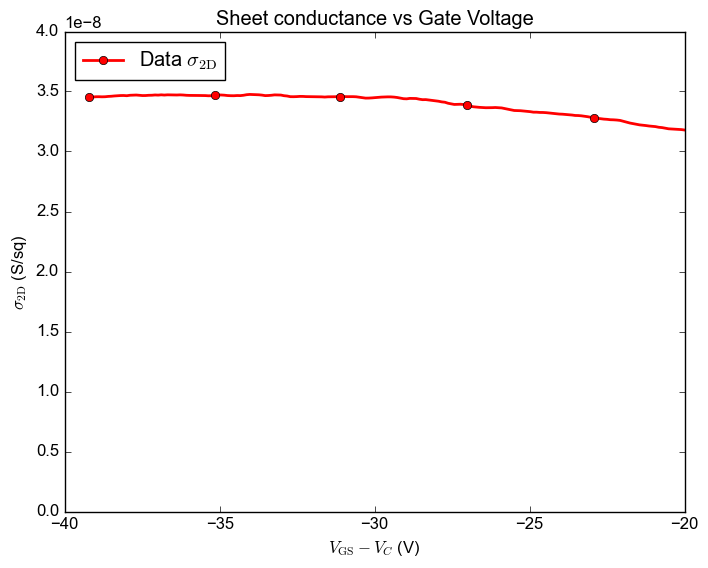

In [31]:
data = np.loadtxt("./Data-Mobility/20262304002.dat")
V_GS = data[:, 0]
I_DS = data[:, 2]
V_DS_source = data[:, 3]
V_DS_multimeter = data[:, 5]
V_21= data[:, 4]
sigma = np.log(2)/np.pi * I_DS / V_21
V_C = V_DS_multimeter/2

plt.plot(V_GS - V_C, sigma, lw=2, label=r'Data $\sigma_\text{2D}$', color='red', marker='o', linestyle='-', markevery=40)
plt.xlabel(r"$V_\text{GS} - V_C$ (V)")
plt.ylabel(r"$\sigma_\text{2D}$ (S/sq)")
plt.xlim(-40, -20)
plt.ylim(0, 0.4e-7)
plt.legend(frameon=True, loc='upper left', numpoints=1)
plt.title("Sheet conductance vs Gate Voltage")
plt.show()


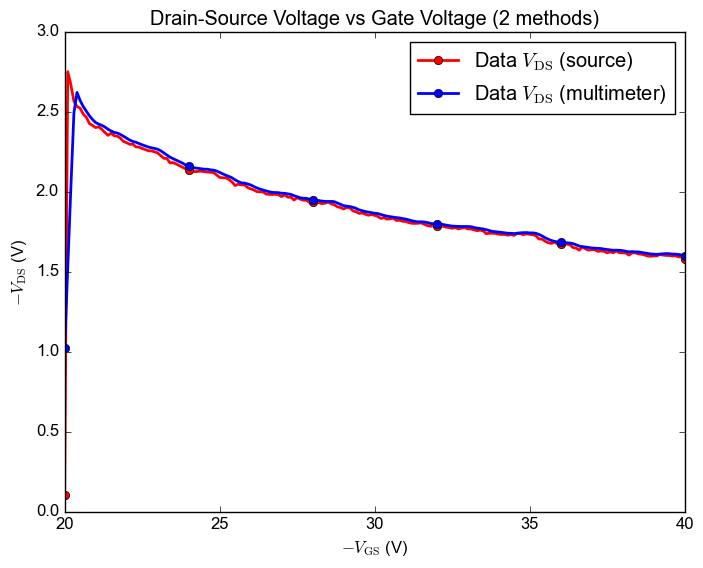

In [32]:
plt.plot(-V_GS, -V_DS_source, lw=2, label=r'Data $V_\text{DS}$ (source)', color='red', marker='o', linestyle='-', markevery=40)
plt.plot(-V_GS, -V_DS_multimeter, lw=2, label=r'Data $V_\text{DS}$ (multimeter)', color='blue', marker='o', linestyle='-', markevery=40)
plt.xlabel(r"$-V_\text{GS}$ (V)")
plt.ylabel(r"$-V_\text{DS}$ (V)")
plt.legend(frameon=True, loc='upper right', numpoints=1)
plt.title("Drain-Source Voltage vs Gate Voltage (2 methods)")
plt.show()

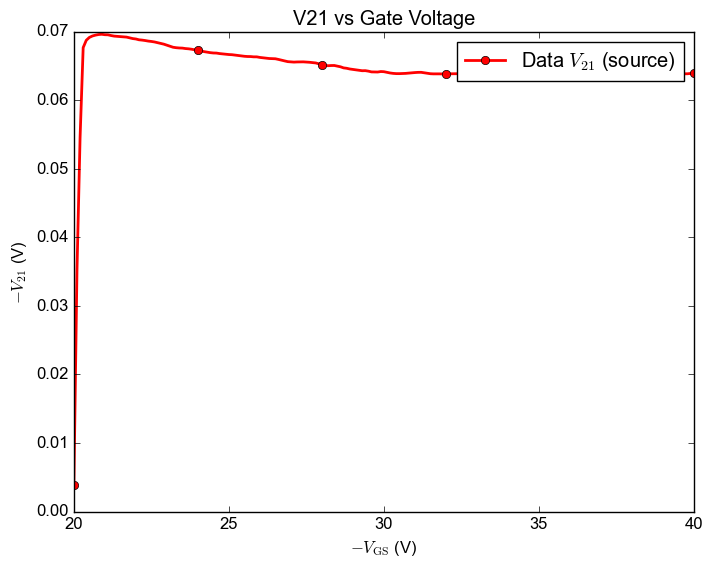

In [33]:
plt.plot(-V_GS, -V_21, lw=2, label=r'Data $V_\text{21}$ (source)', color='red', marker='o', linestyle='-', markevery=40)
plt.xlabel(r"$-V_\text{GS}$ (V)")
plt.ylabel(r"$-V_\text{21}$ (V)")
plt.legend(frameon=True, loc='upper right', numpoints=1)
plt.title("V21 vs Gate Voltage")
plt.show()

a = 6.87354e-10 ± 4.54e-10
b = 5.72898e-08 ± 1.39e-08
R^2 = 0.011407
V_T = (-83.3483 ± 0.703) V
mu = (0.000687354 ± 0.000454) cm^2/Vs


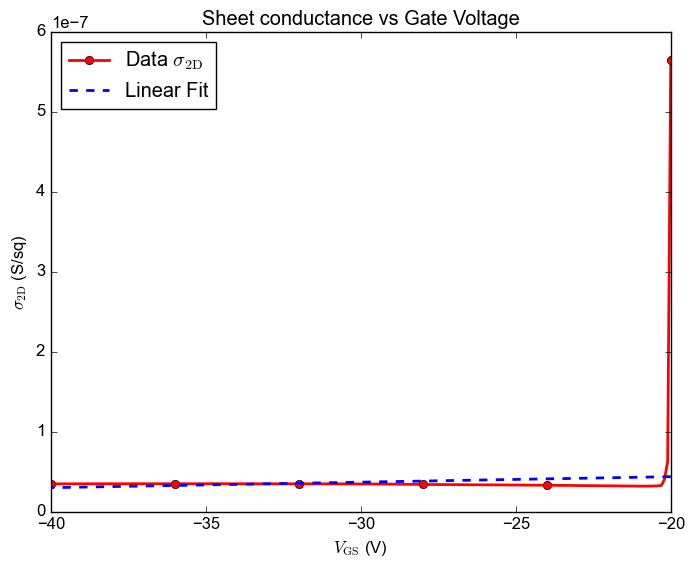

In [34]:
Ci = 1e-2 # F/m^2

def func(x, a, b):
    return a * x + b

popt, pcov = curve_fit(func, V_GS, sigma)
sigma_fit = func(V_GS, *popt)
a, b = popt

# Coefficient of determination
ss_res = np.sum((sigma - sigma_fit) ** 2)
ss_tot = np.sum((sigma - np.mean(sigma)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))
a_err, b_err = perr
V_T_fit = -b/a
mu_fit = a/Ci*1e4

print(f"a = {a:.6g} ± {a_err:.3g}")
print(f"b = {b:.6g} ± {b_err:.3g}")
print(f"R^2 = {r2:.6f}")

print(f"V_T = ({-b/a:.6g} ± {np.sqrt((b_err/b)**2 + (a_err/a)**2):.3g}) V")
print(f"mu = ({a/Ci*1e4:.6g} ± {a_err/Ci*1e4:.3g}) cm^2/Vs")

plt.plot(V_GS, sigma, lw=2, label=r'Data $\sigma_\text{2D}$', color='red', marker='o', linestyle='-', markevery=40)
plt.plot(V_GS, sigma_fit, lw=2, label='Linear Fit', color='blue', linestyle='--')
plt.xlabel(r"$V_\text{GS}$ (V)")
plt.ylabel(r"$\sigma_\text{2D}$ (S/sq)")
plt.legend(frameon=True, loc='upper left', numpoints=1)
plt.title("Sheet conductance vs Gate Voltage")
plt.show()

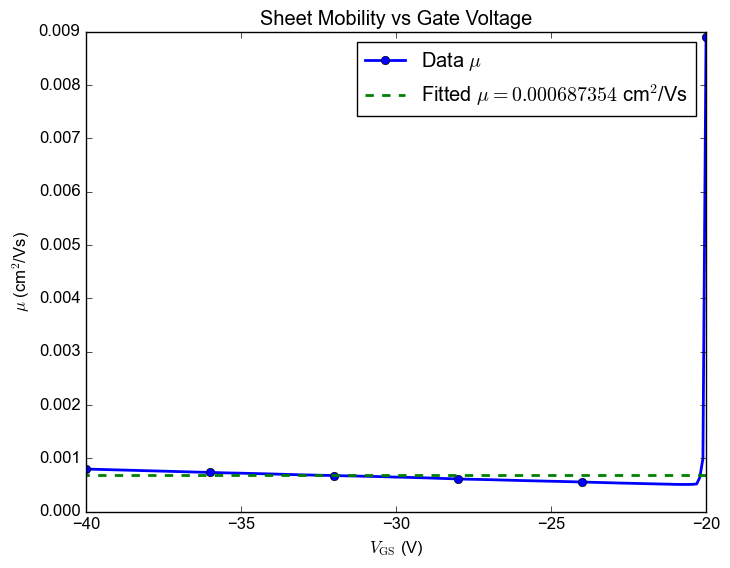

In [35]:

mu = sigma / Ci / (V_GS - V_T_fit) * 1e4 # cm^2/Vs
plt.plot(V_GS, mu, lw=2, label=r"Data $\mu$", color='blue', marker='o', linestyle='-', markevery=40)
plt.plot(V_GS, mu_fit * np.ones_like(V_GS), lw=2, label=rf"Fitted $\mu = {mu_fit:.6g}$ cm$^2$/Vs", color='green', linestyle='--')
plt.xlabel(r"$V_\text{GS}$ (V)")
plt.ylabel(r"$\mu$ (cm$^2$/Vs)")
plt.legend(frameon=True, loc='upper right', numpoints=1)
plt.title("Sheet Mobility vs Gate Voltage")
plt.show()

